## 1. LOAD DATA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
from google.colab import files

print("upload file movies.csv:")
uploaded = files.upload()

df = pd.read_csv('movies.csv')
print("5 Data Pertama")
df.head()

upload file movies.csv:


Saving movies.csv to movies.csv
5 Data Pertama


,id,title,overview,release_date,popularity,vote_average,vote_count
0,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,109.720,8.7,17355
1,278,The Shawshank Redemption,Framed in the 1940s for the double murder of h...,1994-09-23,92.048,8.7,23144
2,315162,Puss in Boots: The Last Wish,Puss in Boots discovers that his passion for a...,2022-12-07,6689.647,8.6,2504
3,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,1974-12-20,57.998,8.6,10503
4,424,Schindler's List,The true story of how businessman Oskar Schind...,1993-12-15,55.299,8.6,13687


## 2. Basic Information About the Dataset

In [ ]:
print("Informasi Dataset")
df.info()

print("\nStatistik Deskriptif")
df.describe()

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   title         10000 non-null  object 
 2   overview      9998 non-null   object 
 3   release_date  10000 non-null  object 
 4   popularity    10000 non-null  float64
 5   vote_average  10000 non-null  float64
 6   vote_count    10000 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 547.0+ KB

Statistik Deskriptif


,id,popularity,vote_average,vote_count
count,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,1.717954e+05,24.737967,6.705490,1613.442000
std,2.254123e+05,109.157223,0.687104,2762.985388
min,2.000000e+00,0.600000,5.400000,200.000000
25%,1.017750e+04,9.455500,6.200000,320.000000
50%,3.260650e+04,13.413000,6.700000,605.000000
75%,3.328988e+05,22.195000,7.200000,1533.250000
max,1.024530e+06,6689.647000,8.700000,33043.000000


## 3. Cek Nilai Duplikat & Nilai Unik

In [ ]:
print("CEK DUPLIKAT")
duplicates = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicates}")

print("\n NILAI UNIK PER KOLOM")
for col in df.columns:
    print(f"{col:15} : {df[col].nunique()} nilai unik")

CEK DUPLIKAT
Jumlah data duplikat: 0

 NILAI UNIK PER KOLOM
id              : 10000 nilai unik
title           : 9660 nilai unik
overview        : 9996 nilai unik
release_date    : 6182 nilai unik
popularity      : 8319 nilai unik
vote_average    : 34 nilai unik
vote_count      : 3246 nilai unik



## 4. Memvisualisasikan Jumlah Nilai Unik

In [ ]:
unique_counts = df.nunique()
print(unique_counts)

id              10000
title            9660
overview         9996
release_date     6182
popularity       8319
vote_average       34
vote_count       3246
dtype: int64


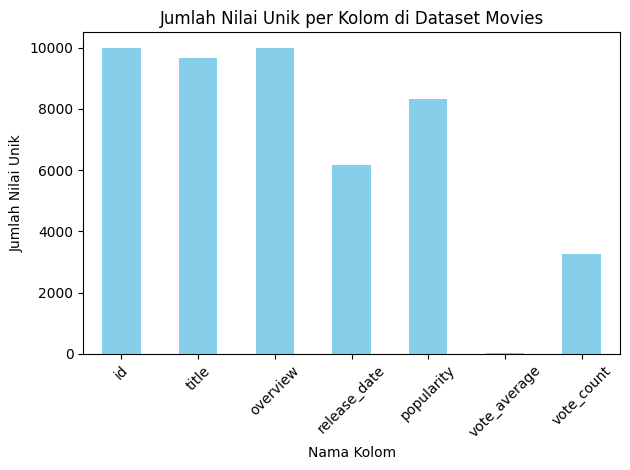

In [ ]:
# Plot
unique_counts.plot(kind='bar', color='skyblue')

# Tampilan
plt.title("Jumlah Nilai Unik per Kolom di Dataset Movies")
plt.xlabel("Nama Kolom")
plt.ylabel("Jumlah Nilai Unik")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 5.  Menemukan Null Values

In [ ]:
df.isnull().sum()

,0
id,0
title,0
overview,2
release_date,0
popularity,0
vote_average,0
vote_count,0


## 6. Replace Semua Null Values

In [ ]:
df['overview'].fillna('No overview available', inplace=True)

/tmp/ipython-input-671684401.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['overview'].fillna('No overview available', inplace=True)


## 7. Mengetahui Tipe Data dari Dataset


In [ ]:
print("Tipe Data Setiap Kolom:")
print(df.dtypes)

Tipe Data Setiap Kolom:
id                int64
title            object
overview         object
release_date     object
popularity      float64
vote_average    float64
vote_count        int64
dtype: object


## 8. Filter Data

In [ ]:
# a. Film dengan rating di atas 8
high_rating = df[df['vote_average'] > 8]
print("Film dengan rating di atas 8:")
print(high_rating[['title', 'vote_average']].head())

# b. Film populer (popularity di atas rata-rata)
mean_popularity = df['popularity'].mean()
popular_movies = df[df['popularity'] > mean_popularity]
print("\nFilm dengan tingkat popularitas di atas rata-rata:")
print(popular_movies[['title', 'popularity']].head())

# c. Film yang dirilis setelah tahun 2015
recent_movies = df[df['release_date'] >= '2015-01-01']
print("\nFilm yang dirilis setelah tahun 2015:")
print(recent_movies[['title', 'release_date']].head())

Film dengan rating di atas 8:
                          title  vote_average
0                 The Godfather           8.7
1      The Shawshank Redemption           8.7
2  Puss in Boots: The Last Wish           8.6
3         The Godfather Part II           8.6
4              Schindler's List           8.6

Film dengan tingkat popularitas di atas rata-rata:
                          title  popularity
0                 The Godfather     109.720
1      The Shawshank Redemption      92.048
2  Puss in Boots: The Last Wish    6689.647
3         The Godfather Part II      57.998
4              Schindler's List      55.299

Film yang dirilis setelah tahun 2015:
                           title release_date
2   Puss in Boots: The Last Wish   2022-12-07
8                     Your Name.   2016-08-26
9                       Parasite   2019-05-30
15             Gabriel's Inferno   2020-05-29
16      Dou kyu sei – Classmates   2016-02-20


9. Membuat Box Plot

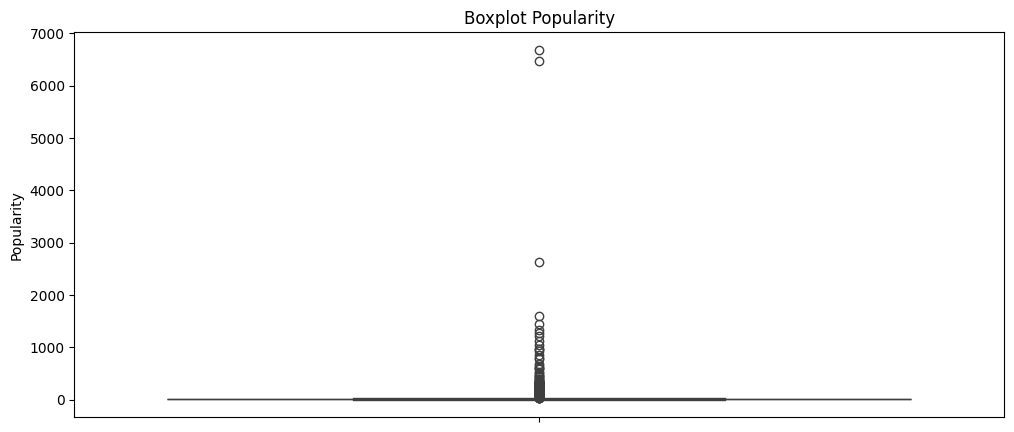

In [ ]:
plt.figure(figsize=(12, 5))

sns.boxplot(y=df['popularity'])
plt.title('Boxplot Popularity')
plt.ylabel('Popularity')

plt.show()

In [ ]:
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year
df = df.dropna(subset=['overview']).drop_duplicates()
awal = 2021
akhir = df['release_year'].max()
df_filter = df[(df['release_year'] >= awal)&(df['release_year'] <= akhir)]

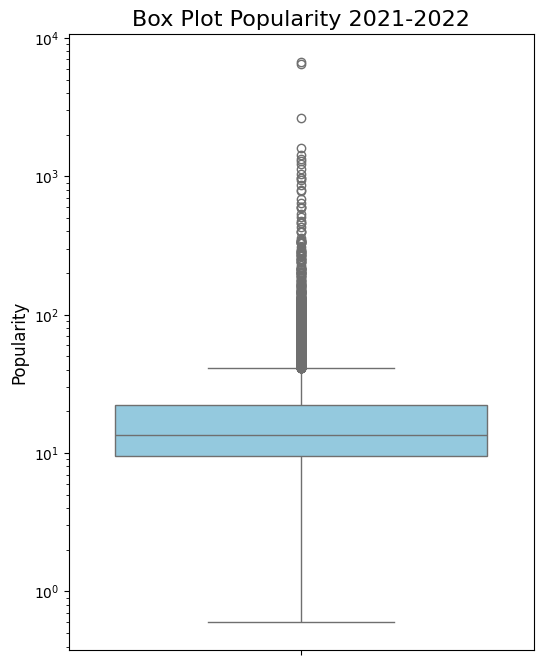

In [ ]:
plt.figure(figsize=(6, 8))
sns.boxplot(y=df['popularity'], color='skyblue')
plt.yscale('log')
plt.title(f'Box Plot Popularity {awal}-{akhir}', fontsize=16)
plt.ylabel('Popularity', fontsize=12)
plt.show()

10. korelasi

In [ ]:
numerik= ['popularity', 'vote_average', 'vote_count']
matrix_korelasi = df[numerik].corr()

print(matrix_korelasi.to_string())

              popularity  vote_average  vote_count
popularity      1.000000      0.080444    0.120607
vote_average    0.080444      1.000000    0.261100
vote_count      0.120607      0.261100    1.000000
